# Validation Metrics

This section evaluates the model using traditional classification metrics.

We report:
- Validation loss
- Top-1 accuracy
- Top-3 accuracy
- Top-5 accuracy

These metrics provide a baseline comparison with previous supervised learning approaches.

In [72]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [74]:
import torch

from torch.utils.data import DataLoader

from tqdm import tqdm

import sqlite3

import json

import gzip

import pandas as pd

In [75]:
from src.data.tokenizer import MahjongTokenizer

from src.features.tensorization import Tensorizer

from src.data.dataset import MahjongDataset

from src.data.collator import MahjongCollator

from src.models.transformer_model import (
    MahjongTransformer
)

from src.training.metrics import (
    compute_topk_accuracy,
)

from src.utils.tile_decoder import (
    tile136_to_string,
)

from src.utils.action_decoder import (
    decode_action,
)

from src.analysis.ukeire import (
    evaluate_discards_ukeire,
)

from src.analysis.error_analysis import (
    categorize_mistake,
)

In [76]:
tokenizer = MahjongTokenizer()

tensorizer = Tensorizer()

collator = MahjongCollator()

In [77]:
val_dataset = MahjongDataset(

    db_path="../data/discard/strategic.db",

    limit=500000,
)

print(len(val_dataset))

500000


In [78]:
val_loader = DataLoader(

    val_dataset,

    batch_size=64,

    shuffle=False,

    collate_fn=collator.collate,

    num_workers=6,

    pin_memory=True,

    persistent_workers=True,
)

In [79]:
model = MahjongTransformer()

In [80]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [81]:
checkpoint = torch.load(

    "../checkpoints/strategic_500k/epoch_15.pt",

    map_location=device,
)

In [82]:
model.load_state_dict(
    checkpoint["model_state_dict"]
)

<All keys matched successfully>

In [83]:
model.to(device)

model.eval()

print("Checkpoint loaded.")

Checkpoint loaded.


In [84]:
criterion = torch.nn.CrossEntropyLoss()

total_loss = 0

total_correct = 0

total_samples = 0

In [85]:
with torch.no_grad():

    for batch in tqdm(val_loader):

        batch = {

            k: v.to(device)
            if isinstance(v, torch.Tensor)
            else v

            for k, v in batch.items()
        }

        targets = batch["target"]

        logits_list = model(batch)

        batch_loss = 0

        for logits, target in zip(
            logits_list,
            targets,
        ):

            target = target.unsqueeze(0)

            logits = logits.unsqueeze(0)

            loss = criterion(
                logits,
                target,
            )

            batch_loss += loss.item()

            prediction = torch.argmax(
                logits,
                dim=1,
            )

            total_correct += (
                prediction == target
            ).sum().item()

            total_samples += 1

        total_loss += batch_loss

100%|██████████| 7813/7813 [54:28<00:00,  2.39it/s]


In [86]:
val_loss = total_loss / len(val_loader)

val_accuracy = total_correct / total_samples

print(f"Validation Loss: {val_loss:.4f}")

print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Loss: 54.1447
Validation Accuracy: 0.6876


In [87]:
top3_correct = 0

top3_total = 0

with torch.no_grad():

    for batch in tqdm(val_loader):

        batch = {

            k: v.to(device)
            if isinstance(v, torch.Tensor)
            else v

            for k, v in batch.items()
        }

        targets = batch["target"]

        logits_list = model(batch)

        top3_correct += compute_topk_accuracy(

            logits_list,

            targets,

            k=3,
        )

        top3_total += len(targets)

top3 = top3_correct / top3_total

print(f"Top-3 Accuracy: {top3:.4f}")

100%|██████████| 7813/7813 [59:25<00:00,  2.19it/s]

Top-3 Accuracy: 0.0147


In [88]:
top5_correct = 0

top5_total = 0

with torch.no_grad():

    for batch in tqdm(val_loader):

        batch = {

            k: v.to(device)
            if isinstance(v, torch.Tensor)
            else v

            for k, v in batch.items()
        }

        targets = batch["target"]

        logits_list = model(batch)

        top5_correct += compute_topk_accuracy(

            logits_list,

            targets,

            k=5,
        )

        top5_total += len(targets)

top5 = top5_correct / top5_total

print(f"Top-5 Accuracy: {top5:.4f}")

  0%|          | 0/7813 [00:00<?, ?it/s]

100%|██████████| 7813/7813 [53:44<00:00,  2.42it/s]

Top-5 Accuracy: 0.0154


# Strategic Evaluation

Exact action matching is insufficient for Mahjong because multiple discards can produce equivalent strategic outcomes.

To address this, we evaluate:
- Shanten preservation
- Effective ukeire
- Strategic mistake categories

In [89]:
conn = sqlite3.connect(
    "../data/discard/strategic.db"
)

In [90]:
results = []

In [91]:
NUM_SAMPLES = 10000

In [92]:
row_result = {}
for offset in tqdm(range(NUM_SAMPLES)):

    query = f"""
    SELECT Data
    FROM Discard
    LIMIT 1 OFFSET {offset}
    """

    row = conn.execute(
        query
    ).fetchone()

    decoded = json.loads(
        gzip.decompress(row[0])
    )

    row_result["offset"] = offset

    canonical_state = {

    "round_wind":
        decoded["round_wind"],

    "num_honba":
        decoded["num_honba"],

    "num_riichi":
        decoded["num_riichi"],

    "player_wind":
        decoded["player_wind"],

    "position":
        decoded["position"],

    "remain_tiles":
        decoded["remain_tiles"],

    "dora_indicators":
        decoded["dora_indicators"],

    "hand_tiles":
        decoded["hand_tiles"],

    "players": {

        "0": decoded["0"],
        "1": decoded["1"],
        "2": decoded["2"],
        "3": decoded["3"],
    },

    "valid_actions":
        decoded["valid_actions"],

    "action_idx":
        decoded["action_idx"],
    }

    tokens = tokenizer.tokenize(
        canonical_state
    )

    tensor_dict = tensorizer.tensorize(
        tokens
    )

    batch = collator.collate(
        [tensor_dict]
    )

    batch = {

        k: v.to(device)
        if isinstance(v, torch.Tensor)
        else v

        for k, v in batch.items()
    }

    with torch.no_grad():

        logits = model(batch)[0]

    probabilities = torch.softmax(
        logits,
        dim=0,
    )

    prediction = torch.argmax(
        probabilities
    ).item()

    expert_action = decoded[
        "valid_actions"
    ][
        decoded["action_idx"]
    ]

    model_action = decoded[
        "valid_actions"
    ][prediction]

    if expert_action["type"] != 1:
        continue

    if model_action["type"] != 1:
        continue

    expert_tile = expert_action[
        "tiles"
    ][0]

    model_tile = model_action[
        "tiles"
    ][0]

    discard_eval = evaluate_discards_ukeire(
        canonical_state
    )

    discard_lookup = {}

    for r in discard_eval:

        discard_lookup[
            r["discard"]
        ] = r

    expert_metrics = discard_lookup[
        expert_tile
    ]

    model_metrics = discard_lookup[
        model_tile
    ]

    row_result = {

    "expert_tile":
        tile136_to_string(
            expert_tile
        ),

    "model_tile":
        tile136_to_string(
            model_tile
        ),

    "same_action":
        expert_tile == model_tile,

    "expert_shanten":
        expert_metrics["shanten"],

    "model_shanten":
        model_metrics["shanten"],

    "expert_ukeire":
        expert_metrics["ukeire"],

    "model_ukeire":
        model_metrics["ukeire"],

    "shanten_difference":
        (
            expert_metrics["shanten"]
            -
            model_metrics["shanten"]
        ),

    "ukeire_difference":
        (
            expert_metrics["ukeire"]
            -
            model_metrics["ukeire"]
        ),

    "model_prob":
        probabilities[
            prediction
        ].item(),
    }

    row_result["category"] = (
        categorize_mistake(
            row_result
        )
    )

    results.append(
        row_result
    )

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [01:54<00:00, 87.58it/s]


In [93]:
results_df = pd.DataFrame(
    results
)

results_df.head()

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
0,east,west,False,4,4,66,67,0,-1,0.585969,near_equivalent,1.0
1,red,west,False,4,4,71,72,0,-1,0.824813,near_equivalent,2.0
2,west,west,True,3,3,32,32,0,0,0.621460,exact_match,3.0
3,south,south,True,3,3,52,52,0,0,0.805673,exact_match,4.0
4,2m,2m,True,3,3,54,54,0,0,0.479410,exact_match,5.0


In [94]:
results_df.groupby("category").size()

category
better_shanten      298
better_ukeire       545
equivalent         1141
exact_match        6913
near_equivalent     565
shanten_loss        144
ukeire_loss         394
dtype: int64

In [95]:
results_df.groupby("category")[

    [
        "shanten_difference",
        "ukeire_difference",
    ]

].mean()

,shanten_difference,ukeire_difference
category,,
better_shanten,1.0,25.818792
better_ukeire,0.0,-8.297248
equivalent,0.0,0.000000
exact_match,0.0,0.000000
near_equivalent,0.0,-0.219469
shanten_loss,-1.0,-26.368056
ukeire_loss,0.0,7.053299


In [96]:
summary = pd.DataFrame({

    "Metric": [

        "Exact Accuracy",
        "Strategic Accuracy",
        "Mean Ukeire Difference",
    ],

    "Value": [

        results_df["same_action"].mean(),

        results_df["category"].isin([
            "exact_match",
            "equivalent",
            "near_equivalent",
        ]).mean(),

        results_df["ukeire_difference"].mean(),
    ]
})

summary

,Metric,Value
0,Exact Accuracy,0.6913
1,Strategic Accuracy,0.8619
2,Mean Ukeire Difference,0.2030


In [97]:
distribution = (

    results_df["category"]

    .value_counts(normalize=True)
)

distribution

category
exact_match        0.6913
equivalent         0.1141
near_equivalent    0.0565
better_ukeire      0.0545
ukeire_loss        0.0394
better_shanten     0.0298
shanten_loss       0.0144
Name: proportion, dtype: float64

In [98]:
results_df[
    "ukeire_difference"
].mean()

np.float64(0.203)

In [99]:
results_df[
    "same_action"
].mean()

np.float64(0.6913)

In [100]:
worst = results_df[

    results_df["category"].isin([
        "catastrophic",
        "shanten_loss",
        "ukeire_loss",
    ])
]

worst = worst.sort_values(

    by=[
        "category",
        "ukeire_difference",
    ],

    ascending=[
        True,
        False,
    ],
)

worst.head(20)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
1837,9s,1s,False,1,2,6,6,-1,0,0.530746,shanten_loss,1838.0
4977,1m,4s,False,1,2,7,7,-1,0,0.557734,shanten_loss,4978.0
9125,6p,8p,False,1,2,5,5,-1,0,0.421625,shanten_loss,9126.0
9412,east,9p,False,1,2,5,5,-1,0,0.476377,shanten_loss,9413.0
9413,3p,east,False,1,2,5,5,-1,0,0.316593,shanten_loss,9414.0
8381,7p,9m,False,1,2,10,11,-1,-1,0.543383,shanten_loss,8382.0
8914,9m,1s,False,1,2,7,8,-1,-1,0.365039,shanten_loss,8915.0
9404,5p,1s,False,2,3,11,12,-1,-1,0.544786,shanten_loss,9405.0
4971,2m,1m,False,1,2,7,9,-1,-2,0.492347,shanten_loss,4972.0
1607,2p,4m,False,1,2,12,15,-1,-3,0.511137,shanten_loss,1608.0


In [101]:
best = results_df[

    results_df["category"].isin([
        "better_shanten",
        "better_ukeire",
        "near_equivalent",
        "equivalent",
    ])
]

best = best.sort_values(

    by=[
        "category",
        "ukeire_difference",
    ],

    ascending=[
        True,
        True,
    ],
)

best.head(20)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
227,6p,1s,False,2,1,12,12,1,0,0.790804,better_shanten,228.0
1744,1s,7m,False,1,0,3,3,1,0,0.796968,better_shanten,1745.0
1263,6m,north,False,3,2,46,45,1,1,0.533602,better_shanten,1264.0
1274,1p,south,False,3,2,14,13,1,1,0.339251,better_shanten,1275.0
1840,south,3s,False,2,1,6,5,1,1,0.475811,better_shanten,1841.0
1841,9s,5p,False,3,2,7,6,1,1,0.480069,better_shanten,1842.0
2635,9s,6m,False,3,2,13,12,1,1,0.648938,better_shanten,2636.0
4975,4s,1m,False,2,1,8,7,1,1,0.613983,better_shanten,4976.0
9266,2s,east,False,4,3,41,40,1,1,0.455866,better_shanten,9267.0
2483,9p,7m,False,2,1,12,10,1,2,0.653696,better_shanten,2484.0


In [102]:
model_better = results_df[
    results_df["category"].isin([
        "better_shanten",
        "better_ukeire",
    ])
]

model_better.head(20)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
38,9s,5p,False,2,1,42,10,1,32,0.763809,better_shanten,39.0
39,1p,8s,False,2,1,35,12,1,23,0.517030,better_shanten,40.0
80,7m,1s,False,3,3,23,42,0,-19,0.870633,better_ukeire,81.0
89,1p,7p,False,2,2,12,16,0,-4,0.497695,better_ukeire,90.0
91,9m,7p,False,2,2,15,19,0,-4,0.599839,better_ukeire,92.0
93,3p,7p,False,2,2,25,32,0,-7,0.805559,better_ukeire,94.0
95,green,2p,False,3,2,60,25,1,35,0.472096,better_shanten,96.0
105,9m,north,False,3,3,64,72,0,-8,0.652868,better_ukeire,106.0
161,3m,1m,False,1,1,17,24,0,-7,0.433101,better_ukeire,162.0
182,7m,2m,False,1,1,7,10,0,-3,0.284389,better_ukeire,183.0


In [103]:
high_confidence_mistakes = results_df[

    results_df["same_action"] == False
]

high_confidence_mistakes = high_confidence_mistakes.sort_values(

    by="model_prob",

    ascending=False,
)

high_confidence_mistakes.head(20)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
7223,3m,8m,False,1,1,12,26,0,-14,0.993694,better_ukeire,7224.0
4515,4p,6s,False,1,0,15,8,1,7,0.989950,better_shanten,4516.0
4406,1s,3p,False,1,0,11,7,1,4,0.988607,better_shanten,4407.0
4788,6s,1p,False,1,1,11,15,0,-4,0.988127,better_ukeire,4789.0
2212,4m,8m,False,1,1,7,22,0,-15,0.986399,better_ukeire,2213.0
4291,2s,8p,False,1,1,18,27,0,-9,0.984089,better_ukeire,4292.0
5985,9m,1s,False,2,2,18,22,0,-4,0.980968,better_ukeire,5986.0
5261,3s,1m,False,2,2,17,20,0,-3,0.980769,better_ukeire,5262.0
9481,7s,5s,False,0,0,4,4,0,0,0.979086,equivalent,9482.0
1259,9m,2m,False,1,1,14,17,0,-3,0.978599,better_ukeire,1260.0


In [104]:
results_df["category"].value_counts()

category
exact_match        6913
equivalent         1141
near_equivalent     565
better_ukeire       545
ukeire_loss         394
better_shanten      298
shanten_loss        144
Name: count, dtype: int64

In [105]:
results_df.to_csv(

    "../reports/500k/strategic_validation_analysis_500k_epoch_15.csv",

    index=False,
)

print("Saved.")

Saved.


In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

In [107]:
sns.set_theme(style="whitegrid")

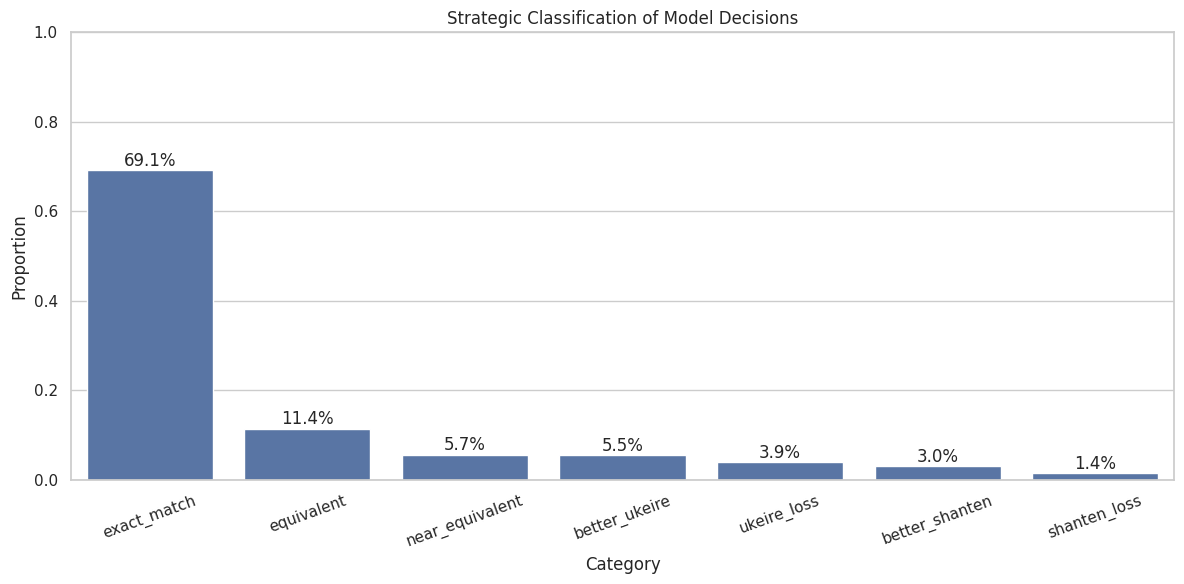

In [108]:
plt.figure(figsize=(12, 6))

sns.barplot(

    x=distribution.index,

    y=distribution.values,
)

plt.ylabel("Proportion")

plt.xlabel("Category")

plt.title(
    "Strategic Classification of Model Decisions"
)

plt.xticks(rotation=20)

plt.ylim(0, 1)

for i, value in enumerate(
    distribution.values
):

    plt.text(

        i,

        value + 0.01,

        f"{value:.1%}",

        ha="center",
    )

plt.tight_layout()



In [109]:
plt.savefig(

    "../reports/figures/500k/category_distribution_500k_epoch_15.png",

    dpi=300,

    bbox_inches="tight",
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [110]:
exact_accuracy = (
    results_df["same_action"]
    .mean()
)

strategic_accuracy = (

    results_df["category"]

    .isin([
        "exact_match",
        "equivalent",
        "near_equivalent",
        "better_ukeire",
        "better_shanten",
    ])

    .mean()
)

comparison_df = pd.DataFrame({

    "Metric": [

        "Exact Accuracy",

        "Strategic Accuracy",
    ],

    "Value": [

        exact_accuracy,

        strategic_accuracy,
    ]
})

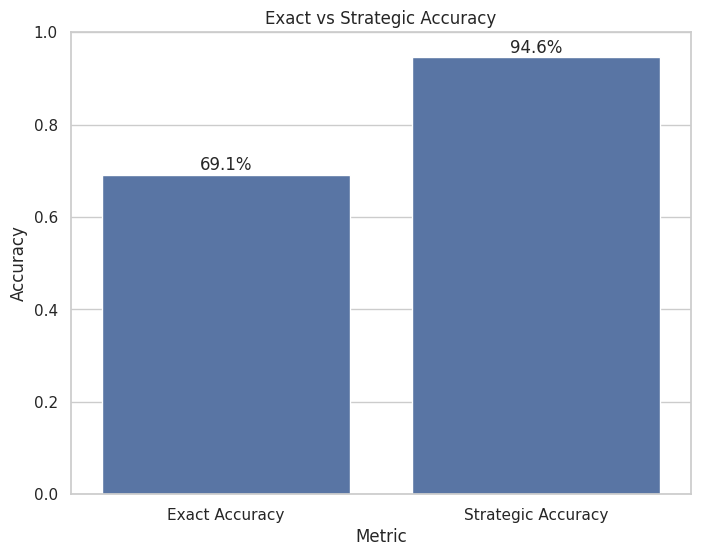

In [111]:
plt.figure(figsize=(8, 6))

sns.barplot(

    data=comparison_df,

    x="Metric",

    y="Value",
)

plt.ylim(0, 1)

plt.ylabel("Accuracy")

plt.title(
    "Exact vs Strategic Accuracy"
)

for i, value in enumerate(
    comparison_df["Value"]
):

    plt.text(

        i,

        value + 0.01,

        f"{value:.1%}",

        ha="center",
    )



In [112]:
plt.savefig(

    "../reports/figures/500k/accuracy_difference_500k_epoch_15.png",

    dpi=300,

    bbox_inches="tight",
)

plt.show()

<Figure size 640x480 with 0 Axes>

Text(0.5, 1.0, 'Ukeire Difference Distribution')

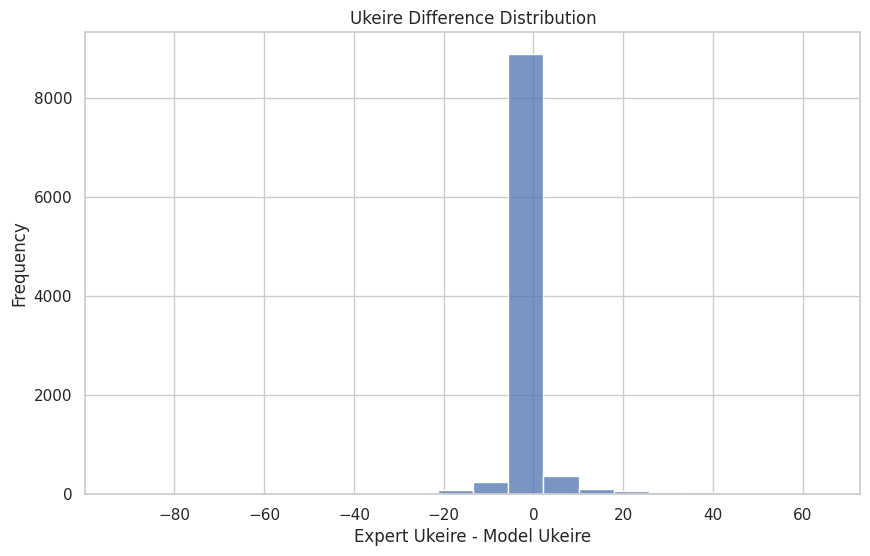

In [113]:
plt.figure(figsize=(10, 6))

sns.histplot(

    results_df["ukeire_difference"],

    bins=20,
)

plt.xlabel(
    "Expert Ukeire - Model Ukeire"
)

plt.ylabel("Frequency")

plt.title(
    "Ukeire Difference Distribution"
)



In [114]:
plt.savefig(

    "../reports/figures/500k/ukeire_distribution_500k_epoch_15.png",

    dpi=300,

    bbox_inches="tight",
)

plt.show()

<Figure size 640x480 with 0 Axes>

Text(0.5, 1.0, 'Confidence Distribution by Category')

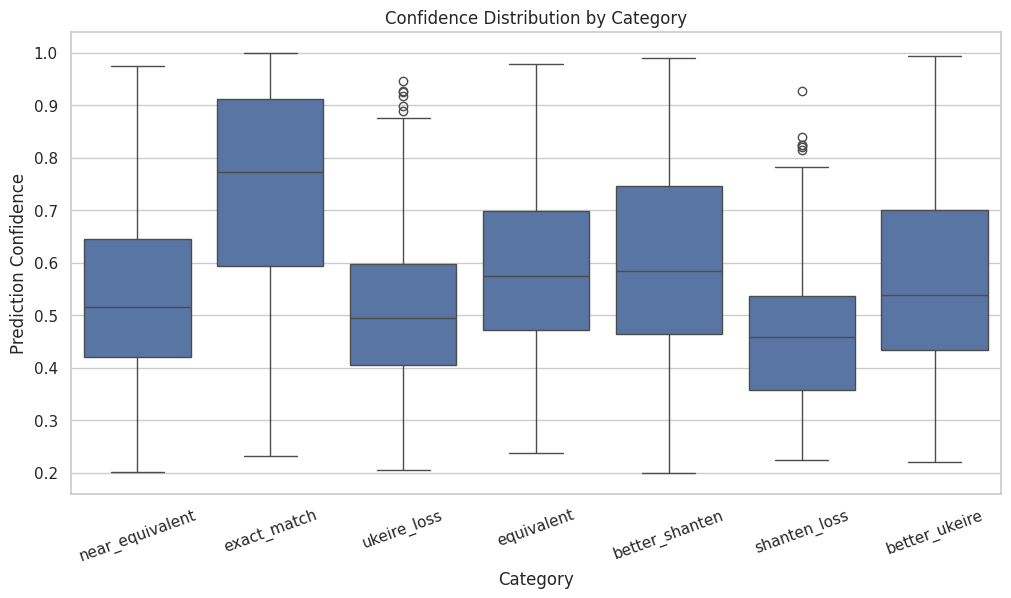

In [115]:
plt.figure(figsize=(12, 6))

sns.boxplot(

    data=results_df,

    x="category",

    y="model_prob",
)

plt.xticks(rotation=20)

plt.xlabel("Category")

plt.ylabel("Prediction Confidence")

plt.title(
    "Confidence Distribution by Category"
)



In [116]:
plt.savefig(

    "../reports/figures/500k/category_confidence_distribution_500k_epoch_15.png",

    dpi=300,

    bbox_inches="tight",
)

plt.show()

<Figure size 640x480 with 0 Axes>

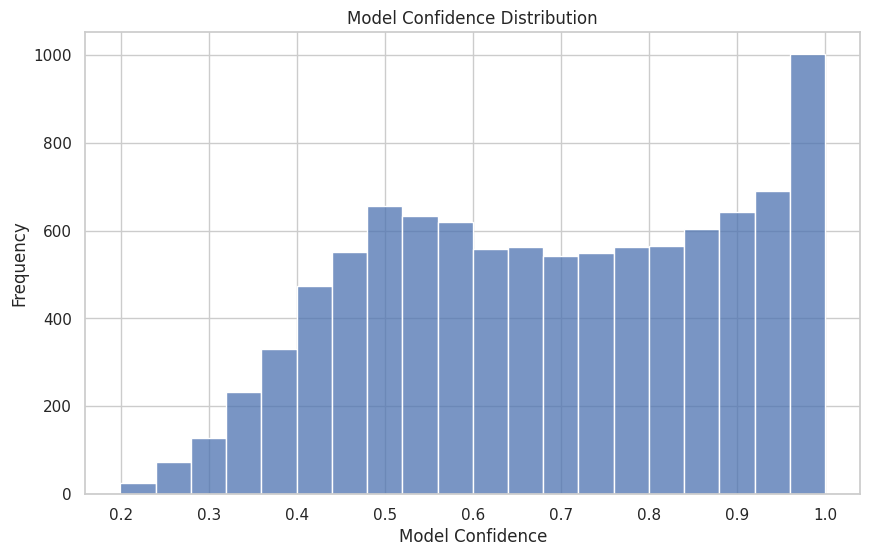

In [117]:
plt.figure(figsize=(10, 6))

sns.histplot(

    results_df["model_prob"],

    bins=20,
)

plt.xlabel(
    "Model Confidence"
)

plt.ylabel("Frequency")

plt.title(
    "Model Confidence Distribution"
)

plt.savefig(

    "../reports/figures/500k/confidence_distribution_500k_epoch_15.png",

    dpi=300,

    bbox_inches="tight",
)

plt.show()

In [118]:
results_df.to_csv(

    "../reports/tables/500k_results_epoch_15.csv",

    index=False,
)

In [119]:
distribution.to_csv(

    "../reports/tables/500k_distribution_epoch_15.csv"
)

In [120]:
summary = pd.DataFrame({

    "metric": [

        "exact_accuracy",

        "strategic_accuracy",

        "mean_confidence",

        "mean_ukeire_difference",
    ],

    "value": [

        results_df["same_action"].mean(),

        results_df["category"].isin([

            "exact_match",

            "equivalent",

            "near_equivalent",

            "better_ukeire",

            "better_shanten",

        ]).mean(),

        results_df["model_prob"].mean(),

        results_df["ukeire_difference"].mean(),
    ]
})

In [121]:
summary.to_csv(

    "../reports/tables/500k_summary_epoch_15.csv",

    index=False,
)

# Case Studies

Aggregate metrics provide a high-level overview of model performance, but they do not explain the nature of individual decisions.

This section presents representative examples from each strategic category:

- Exact Match
- Near Equivalent
- Better Ukeire
- Shanten Loss

For each example we inspect:

- The full Mahjong state
- The expert discard
- The model discard
- Shanten values
- Effective ukeire values

This allows qualitative analysis of the model's strategic behavior.

In [122]:
def load_state(offset):

    query = f"""
    SELECT Data
    FROM Discard
    LIMIT 1 OFFSET {offset}
    """

    row = conn.execute(
        query
    ).fetchone()

    decoded = json.loads(
        gzip.decompress(
            row[0]
        )
    )

    canonical_state = {

        "round_wind":
            decoded["round_wind"],

        "num_honba":
            decoded["num_honba"],

        "num_riichi":
            decoded["num_riichi"],

        "player_wind":
            decoded["player_wind"],

        "position":
            decoded["position"],

        "remain_tiles":
            decoded["remain_tiles"],

        "dora_indicators":
            decoded["dora_indicators"],

        "hand_tiles":
            decoded["hand_tiles"],

        "players": {

            "0": decoded["0"],
            "1": decoded["1"],
            "2": decoded["2"],
            "3": decoded["3"],
        },

        "valid_actions":
            decoded["valid_actions"],

        "action_idx":
            decoded["action_idx"],
    }

    return canonical_state

In [123]:
from src.utils.state_renderer import (
    render_state
)

## Case Study 1 — Exact Match

This example shows a state where the transformer selects the same discard as the expert player.

In [124]:
exact_case = results_df[

    results_df["category"]
    ==
    "exact_match"

].sample(1)

exact_case

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
1725,2p,2p,True,0,0,8,8,0,0,0.998636,exact_match,1726.0


In [125]:
state = load_state(

    int(
        exact_case.iloc[0]["offset"]
    ) - 1
)

render_state(state)


ROUND

Round Wind: 1
Honba: 0
Riichi Sticks: 0
Remaining Tiles: 46

Dora Indicators: west

PLAYER 0

Points: 22200
Riichi: False
MELDS:
None

DISCARDS:
red 9s west* red* green* 9s* 8s

PLAYER 1

Points: 38800
Riichi: False
MELDS:
None

DISCARDS:
west* green 8p 4p 2p 5p* white

PLAYER 2

Points: 25800
Riichi: False

HAND:
6m 6m 4s 5s 2p

MELDS:
chi: ['6p', '7p', '8p']
chi: ['3p', '5p', '4p']
chi: ['6p', '7p', '5p']

DISCARDS:
north 8s 1m 2s 2m east*

PLAYER 3

Points: 13200
Riichi: False
MELDS:
None

DISCARDS:
1p 8p 9p 9p* white 6p


In [126]:
exact_case.T

,1725
expert_tile,2p
model_tile,2p
same_action,True
expert_shanten,0
model_shanten,0
expert_ukeire,8
model_ukeire,8
shanten_difference,0
ukeire_difference,0
model_prob,0.998636


### Discussion

The model reproduces the expert action exactly.

This suggests that the learned policy captures the same local strategic considerations as the expert in this situation.

## Case Study 2 — Near Equivalent

This example shows a disagreement between the model and the expert.

However, the resulting hand quality remains strategically similar.

In [127]:
near_case = results_df[

    results_df["category"]
    ==
    "near_equivalent"

].sample(1)

near_case

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
5040,south,east,False,4,4,74,72,0,2,0.436548,near_equivalent,5041.0


In [128]:
state = load_state(

    int(
        near_case.iloc[0]["offset"]
    ) - 1
)

render_state(state)


ROUND

Round Wind: 0
Honba: 0
Riichi Sticks: 0
Remaining Tiles: 64

Dora Indicators: 5s

PLAYER 0

Points: 31700
Riichi: False
MELDS:
None

DISCARDS:
north south

PLAYER 1

Points: 21800
Riichi: False

HAND:
5m 6m 2p 3p 3p 5p 5p 8p 2s 4s east south west 8s

MELDS:
None

DISCARDS:
north

PLAYER 2

Points: 17300
Riichi: False
MELDS:
None

DISCARDS:
south

PLAYER 3

Points: 29200
Riichi: False
MELDS:
None

DISCARDS:
9p


In [129]:
near_case.T

,5040
expert_tile,south
model_tile,east
same_action,False
expert_shanten,4
model_shanten,4
expert_ukeire,74
model_ukeire,72
shanten_difference,0
ukeire_difference,2
model_prob,0.436548


### Discussion

The transformer chooses a different discard from the expert.

Despite this disagreement, both actions preserve hand efficiency and result in similar strategic outcomes.

## Case Study 3 — Better Ukeire

This example shows a situation where the model chooses a discard that results in a larger effective ukeire than the expert action.

In [130]:
better_case = results_df[

    results_df["category"]
    ==
    "better_ukeire"

].sort_values(

    by="ukeire_difference",

    ascending=True,
)

better_case.head(1)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
7030,south,9s,False,3,3,20,67,0,-47,0.927944,better_ukeire,7031.0


In [131]:
state = load_state(

    int(
        better_case.iloc[0]["offset"]
    ) - 1
)

render_state(state)


ROUND

Round Wind: 1
Honba: 0
Riichi Sticks: 0
Remaining Tiles: 53

Dora Indicators: 4p

PLAYER 0

Points: 44400
Riichi: False

HAND:
3m 6m 1p 1p 2p 2s 2s 3s 4s 6s south south south 9s

MELDS:
None

DISCARDS:
green east* 8p 9s*

PLAYER 1

Points: 10300
Riichi: False
MELDS:
None

DISCARDS:
west north green 1m

PLAYER 2

Points: 23100
Riichi: True
MELDS:
None

DISCARDS:
west red 8p 5s

PLAYER 3

Points: 22200
Riichi: False
MELDS:
None

DISCARDS:
9p red white west


In [132]:
better_case.head(1).T

,7030
expert_tile,south
model_tile,9s
same_action,False
expert_shanten,3
model_shanten,3
expert_ukeire,20
model_ukeire,67
shanten_difference,0
ukeire_difference,-47
model_prob,0.927944


### Discussion

The model selects a discard that increases effective ukeire while preserving shanten.

This does not necessarily imply that the model found a superior Mahjong decision, since defensive considerations, hand value, and game context are not captured by the evaluation metrics.

However, it demonstrates that expert imitation and efficiency optimization are not always identical.

## Case Study 4 — Shanten Loss

This example illustrates a genuine strategic mistake.

The model chooses a discard that worsens the hand's shanten number compared to the expert action.

In [133]:
bad_case = results_df[

    results_df["category"]
    ==
    "shanten_loss"

].head(1)

bad_case

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
52,4m,6p,False,0,1,3,44,-1,-41,0.306473,shanten_loss,53.0


In [134]:
state = load_state(

    int(
        bad_case.iloc[0]["offset"]
    ) - 1
)

render_state(state)


ROUND

Round Wind: 0
Honba: 1
Riichi Sticks: 1
Remaining Tiles: 43

Dora Indicators: west

PLAYER 0

Points: 23000
Riichi: False
MELDS:
None

DISCARDS:
south green east 2s* 2m 1s* east*

PLAYER 1

Points: 31200
Riichi: False
MELDS:
pon: ['3p', '3p', '3p']

DISCARDS:
1s 9m south north 1s* 1m* 9p 2p

PLAYER 2

Points: 21300
Riichi: False

HAND:
1m 1m 5m 6m 7m 6p 6p red red red 4m

MELDS:
pon: ['north', 'north', 'north']

DISCARDS:
9p east green west 2m 3p 6s

PLAYER 3

Points: 23500
Riichi: False
MELDS:
None

DISCARDS:
east* red white 9s 1p 8s


In [135]:
bad_case.T

,52
expert_tile,4m
model_tile,6p
same_action,False
expert_shanten,0
model_shanten,1
expert_ukeire,3
model_ukeire,44
shanten_difference,-1
ukeire_difference,-41
model_prob,0.306473


### Discussion

Unlike previous examples, the model's action directly worsens hand progression.

These cases represent true strategic failures and provide insight into the remaining weaknesses of the learned policy.

# Case Study Summary

The qualitative examples support the quantitative findings presented earlier.

Several disagreements between the model and expert players correspond to strategically equivalent alternatives rather than genuine mistakes.

Furthermore, some model decisions produce higher effective ukeire than the expert action, suggesting that exact imitation accuracy alone is insufficient to characterize Mahjong policy quality.

The most informative failures are the shanten loss cases, which represent situations where the model genuinely degrades hand efficiency.